# Sesión 02 — Modelos de Clasificación
### Aplicación con dataset propio: Viral Social Media Trends
**Variable objetivo: `Content_Type`** (clasificación multiclase)
**Curso:** Ingeniería del Conocimiento (ISO56B)
**Docente:** Msc. Jaime Antonio Huaytalla Pariona
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Viral Social Media Trends**, prediciendo el **tipo de contenido** (`Content_Type`: Video, Shorts, Post, Tweet, Live Stream, Reel) a partir de la plataforma, región, métricas de interacción y nivel de engagement de cada publicación.

Este notebook adapta la metodología de la Sesión 02 (originalmente clasificación binaria sobre *Wine Quality*) a un problema **multiclase (6 clases)** con un dataset propio, manteniendo la misma estructura de análisis: EDA orientado a clasificación, preparación de datos, entrenamiento de los 4 modelos, validación cruzada y comparación final.

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
    accuracy_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos **Viral Social Media Trends**, un dataset de 5000 publicaciones en redes sociales (TikTok, Instagram, Twitter, YouTube) con sus métricas de interacción (`Views`, `Likes`, `Shares`, `Comments`) y metadatos (`Platform`, `Hashtag`, `Content_Type`, `Region`, `Engagement_Level`).

**Variable objetivo:** `Content_Type`, con 6 categorías: `Video`, `Shorts`, `Post`, `Tweet`, `Live Stream`, `Reel`. A diferencia de la sesión anterior (donde binarizamos `quality`/`Engagement_Level`), aquí trabajamos un problema **multiclase nativo**, sin necesidad de agrupar categorías.

In [2]:
# Carga del dataset
# Si trabajas en Google Colab y el archivo no está en el entorno, súbelo primero con:
# from google.colab import files
# uploaded = files.upload()

DATA_PATH = 'Cleaned_Viral_Social_Media_Trends.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 5000 registros, 11 columnas


,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [3]:
# Información general del dataset
df.info()
print()
print('Valores nulos por columna:')
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Post_ID           5000 non-null   str  
 1   Post_Date         5000 non-null   str  
 2   Platform          5000 non-null   str  
 3   Hashtag           5000 non-null   str  
 4   Content_Type      5000 non-null   str  
 5   Region            5000 non-null   str  
 6   Views             5000 non-null   int64
 7   Likes             5000 non-null   int64
 8   Shares            5000 non-null   int64
 9   Comments          5000 non-null   int64
 10  Engagement_Level  5000 non-null   str  
dtypes: int64(4), str(7)
memory usage: 429.8 KB

Valores nulos por columna:
Post_ID             0
Post_Date           0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
d

Distribución de Content_Type:
Content_Type
Live Stream    855
Post           853
Reel           841
Tweet          836
Video          828
Shorts         787
Name: count, dtype: int64

→ Las 6 clases están razonablemente balanceadas (~14-17% cada una),
  a diferencia del fuerte desbalance de Wine Quality.


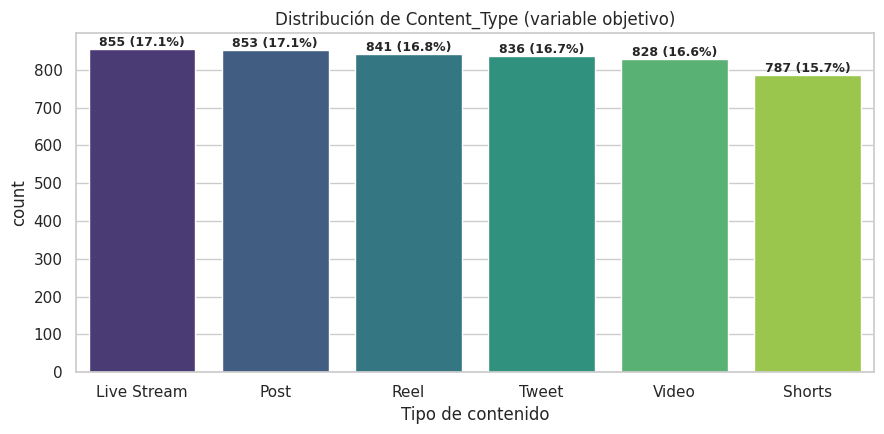

In [4]:
# Distribución de la variable objetivo: Content_Type
print('Distribución de Content_Type:')
print(df['Content_Type'].value_counts())

fig, ax = plt.subplots(figsize=(9, 4.5))
order = df['Content_Type'].value_counts().index
sns.countplot(data=df, x='Content_Type', order=order, ax=ax, palette='viridis')
for i, v in enumerate(df['Content_Type'].value_counts()[order].values):
    ax.text(i, v + 8, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Distribución de Content_Type (variable objetivo)')
ax.set_xlabel('Tipo de contenido')
plt.tight_layout()
plt.show()

print('\n→ Las 6 clases están razonablemente balanceadas (~14-17% cada una),')
print('  a diferencia del fuerte desbalance de Wine Quality.')

---
## 3. Análisis exploratorio orientado a clasificación

Exploramos cómo se relaciona `Content_Type` con las demás variables: ¿ciertas plataformas o regiones concentran más un tipo de contenido? ¿el nivel de engagement o las métricas numéricas difieren según el tipo de contenido?

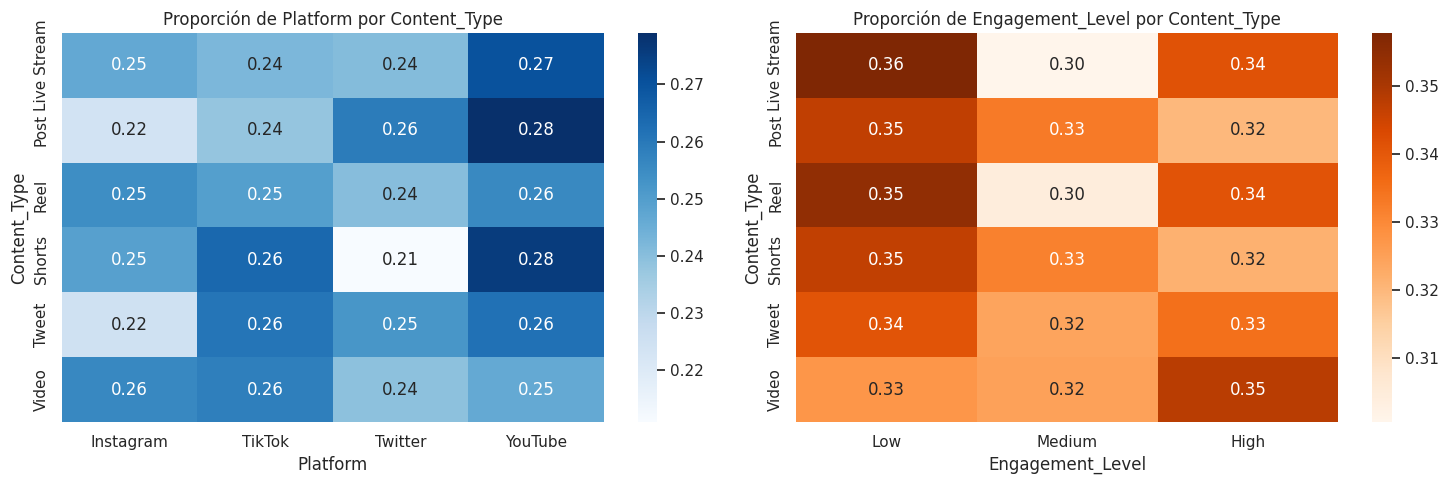

In [5]:
# 3.1  Content_Type vs Platform y Content_Type vs Engagement_Level
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ct_platform = pd.crosstab(df['Content_Type'], df['Platform'], normalize='index')
sns.heatmap(ct_platform, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
axes[0].set_title('Proporción de Platform por Content_Type')

ct_engagement = pd.crosstab(df['Content_Type'], df['Engagement_Level'], normalize='index')[['Low', 'Medium', 'High']]
sns.heatmap(ct_engagement, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Proporción de Engagement_Level por Content_Type')

plt.tight_layout()
plt.show()

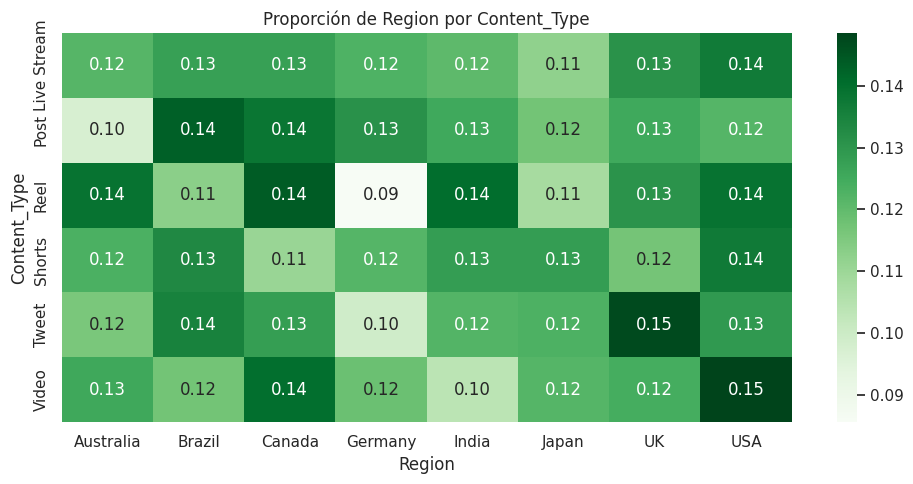

In [6]:
# 3.2  Content_Type vs Region
plt.figure(figsize=(10, 5))
ct_region = pd.crosstab(df['Content_Type'], df['Region'], normalize='index')
sns.heatmap(ct_region, annot=True, fmt='.2f', cmap='Greens')
plt.title('Proporción de Region por Content_Type')
plt.tight_layout()
plt.show()

In [7]:
# 3.3  Feature engineering: tasas de interacción
df['Engagement_Rate'] = (df['Likes'] + df['Shares'] + df['Comments']) / df['Views']
df['Like_Rate'] = df['Likes'] / df['Views']
df['Share_Rate'] = df['Shares'] / df['Views']
df['Comment_Rate'] = df['Comments'] / df['Views']

numeric_features = ['Views', 'Likes', 'Shares', 'Comments',
                     'Engagement_Rate', 'Like_Rate', 'Share_Rate', 'Comment_Rate']

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Views,5000.0,2.494066e+06,1.459490e+06,1266.000000,1.186207e+06,2.497373e+06,3.759781e+06,4.999430e+06
Likes,5000.0,2.514750e+05,1.443496e+05,490.000000,1.268922e+05,2.494430e+05,3.739708e+05,4.999220e+05
Shares,5000.0,5.051956e+04,2.906636e+04,52.000000,2.502900e+04,5.083950e+04,7.577425e+04,9.997800e+04
Comments,5000.0,2.488839e+04,1.428450e+04,18.000000,1.230525e+04,2.500400e+04,3.707275e+04,4.999300e+04
Engagement_Rate,5000.0,5.675985e-01,4.862140e+00,0.003001,7.748975e-02,1.290969e-01,2.700184e-01,2.817417e+02
Like_Rate,5000.0,4.416795e-01,4.153522e+00,0.000158,5.072154e-02,1.000274e-01,2.060908e-01,2.518555e+02
Share_Rate,5000.0,8.051449e-02,5.002558e-01,0.000013,1.024274e-02,2.004027e-02,4.106744e-02,1.891881e+01
Comment_Rate,5000.0,4.540457e-02,4.660359e-01,0.000016,5.013399e-03,1.002971e-02,2.030583e-02,2.853160e+01


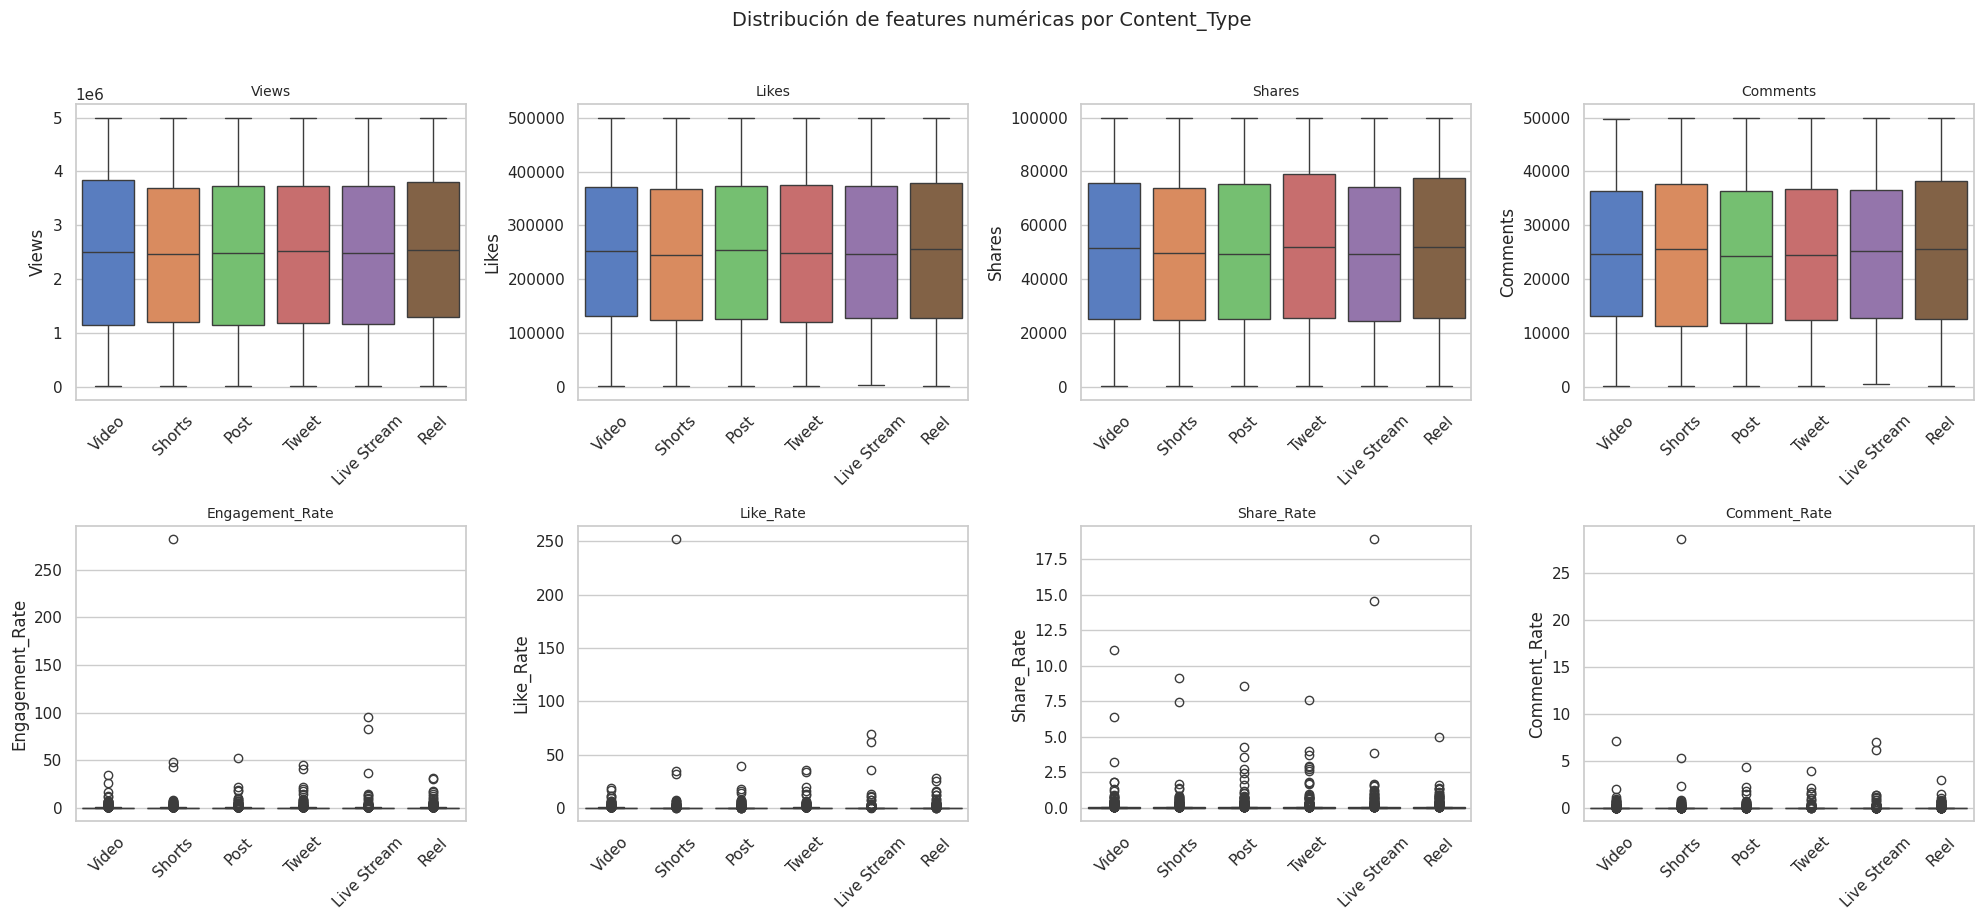

In [8]:
# 3.4  Distribución de features numéricas por Content_Type (boxplots)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Content_Type', y=col, ax=axes[i], hue='Content_Type', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Distribución de features numéricas por Content_Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

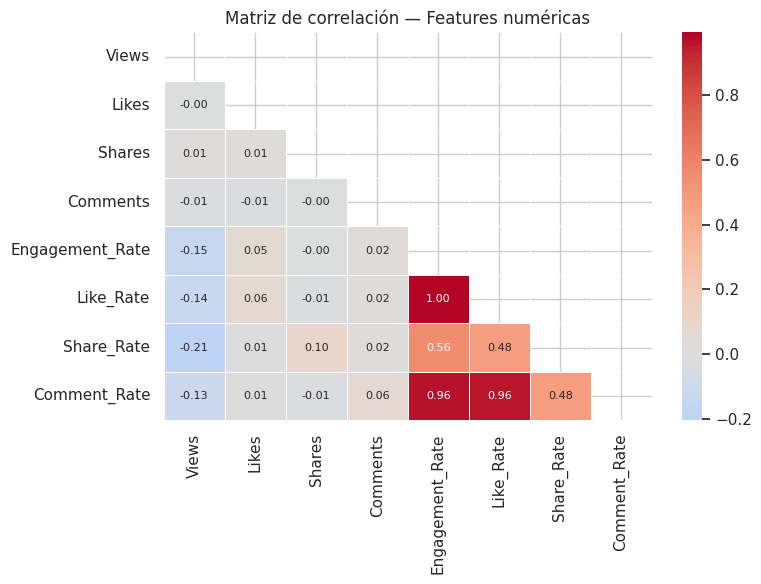

In [9]:
# 3.5  Correlación entre features numéricas
plt.figure(figsize=(8, 6))
corr = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features numéricas')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

Codificamos las variables categóricas predictoras (`Platform`, `Region`, `Engagement_Level`) mediante **one-hot encoding**. Se excluyen `Post_ID` (identificador), `Post_Date` y `Hashtag` (quedan como posible extensión en los ejercicios). La variable objetivo es `Content_Type`.

In [10]:
# 4.1  Codificación one-hot de variables categóricas predictoras
categorical_features = ['Platform', 'Region', 'Engagement_Level']
dummies = pd.get_dummies(df[categorical_features], drop_first=True)

X = pd.concat([df[numeric_features], dummies], axis=1)
y = df['Content_Type'].copy()

features = X.columns  # usado más abajo (importancias, coeficientes, etc.)
class_names = sorted(y.unique())

print(f'Total de features tras el encoding: {X.shape[1]}')
print(f'Clases objetivo ({len(class_names)}): {class_names}')
X.head()

Total de features tras el encoding: 20
Clases objetivo (6): ['Live Stream', 'Post', 'Reel', 'Shorts', 'Tweet', 'Video']


,Views,Likes,Shares,Comments,Engagement_Rate,Like_Rate,Share_Rate,Comment_Rate,Platform_TikTok,Platform_Twitter,Platform_YouTube,Region_Brazil,Region_Canada,Region_Germany,Region_India,Region_Japan,Region_UK,Region_USA,Engagement_Level_Low,Engagement_Level_Medium
0,4163464,339431,53135,19346,0.098935,0.081526,0.012762,0.004647,True,False,False,False,False,False,False,False,True,False,False,False
1,4155940,215240,65860,27239,0.074192,0.051791,0.015847,0.006554,False,False,False,False,False,False,True,False,False,False,False,True
2,3666211,327143,39423,36223,0.109865,0.089232,0.010753,0.009880,False,True,False,True,False,False,False,False,False,False,False,True
3,917951,127125,11687,36806,0.191315,0.138488,0.012732,0.040096,False,False,True,False,False,False,False,False,False,False,True,False
4,64866,171361,69581,6376,3.812752,2.641769,1.072688,0.098295,True,False,False,True,False,False,False,False,False,False,False,True


In [11]:
# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print('\nDistribución de clases en train:')
print(y_train.value_counts(normalize=True).round(3))

Train: 4000 muestras  |  Test: 1000 muestras

Distribución de clases en train:
Content_Type
Live Stream    0.171
Post           0.170
Reel           0.168
Tweet          0.167
Video          0.166
Shorts         0.158
Name: proportion, dtype: float64


In [12]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features numéricas (train):')
print('='*55)
for col in numeric_features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:20s}  [{mn:12.4f}, {mx:12.4f}]  rango: {mx-mn:.4f}')

print('\n→ Las escalas difieren en varios órdenes de magnitud (Views ~10^6 vs tasas ~10^0).')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features numéricas (train):
Views                 [   1266.0000, 4999077.0000]  rango: 4997811.0000
Likes                 [    490.0000,  499922.0000]  rango: 499432.0000
Shares                [     52.0000,   99978.0000]  rango: 99926.0000
Comments              [     32.0000,   49993.0000]  rango: 49961.0000
Engagement_Rate       [      0.0030,     281.7417]  rango: 281.7387
Like_Rate             [      0.0002,     251.8555]  rango: 251.8553
Share_Rate            [      0.0000,      18.9188]  rango: 18.9188
Comment_Rate          [      0.0000,      28.5316]  rango: 28.5316

→ Las escalas difieren en varios órdenes de magnitud (Views ~10^6 vs tasas ~10^0).
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a cada clase mediante softmax (extensión multiclase de la sigmoide). Ideal como **baseline** por su interpretabilidad y eficiencia. Usamos `f1_macro` como métrica: promedia el F1 de cada una de las 6 clases con el mismo peso, sin importar su frecuencia.

In [13]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1_macro')
print(f'Logistic Regression — F1 macro CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
proba_lr = pipe_lr.predict_proba(X_test)

Logistic Regression — F1 macro CV: 0.1549 ± 0.0088



Interpretación: en cada fila (clase), un coeficiente positivo alto indica que valores
mayores de esa feature aumentan la probabilidad de predecir ese Content_Type específico.


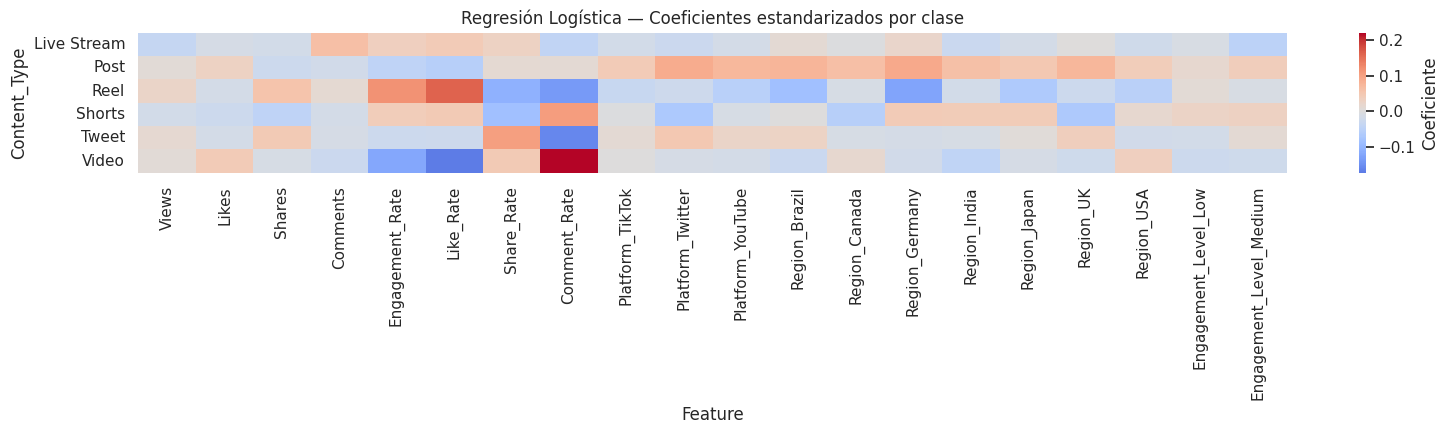

In [14]:
# 5.2  Coeficientes del modelo (interpretabilidad) — una fila por clase
clf_lr = pipe_lr.named_steps['clf']
coef_matrix = pd.DataFrame(clf_lr.coef_, index=clf_lr.classes_, columns=features)

plt.figure(figsize=(16, 4.5))
sns.heatmap(coef_matrix, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Coeficiente'})
plt.title('Regresión Logística — Coeficientes estandarizados por clase')
plt.xlabel('Feature')
plt.ylabel('Content_Type')
plt.tight_layout()
plt.show()

print('\nInterpretación: en cada fila (clase), un coeficiente positivo alto indica que valores')
print('mayores de esa feature aumentan la probabilidad de predecir ese Content_Type específico.')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [15]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1_macro')
print(f'Decision Tree — F1 macro CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)
proba_dt = pipe_dt.predict_proba(X_test)

Decision Tree — F1 macro CV: 0.1258 ± 0.0199


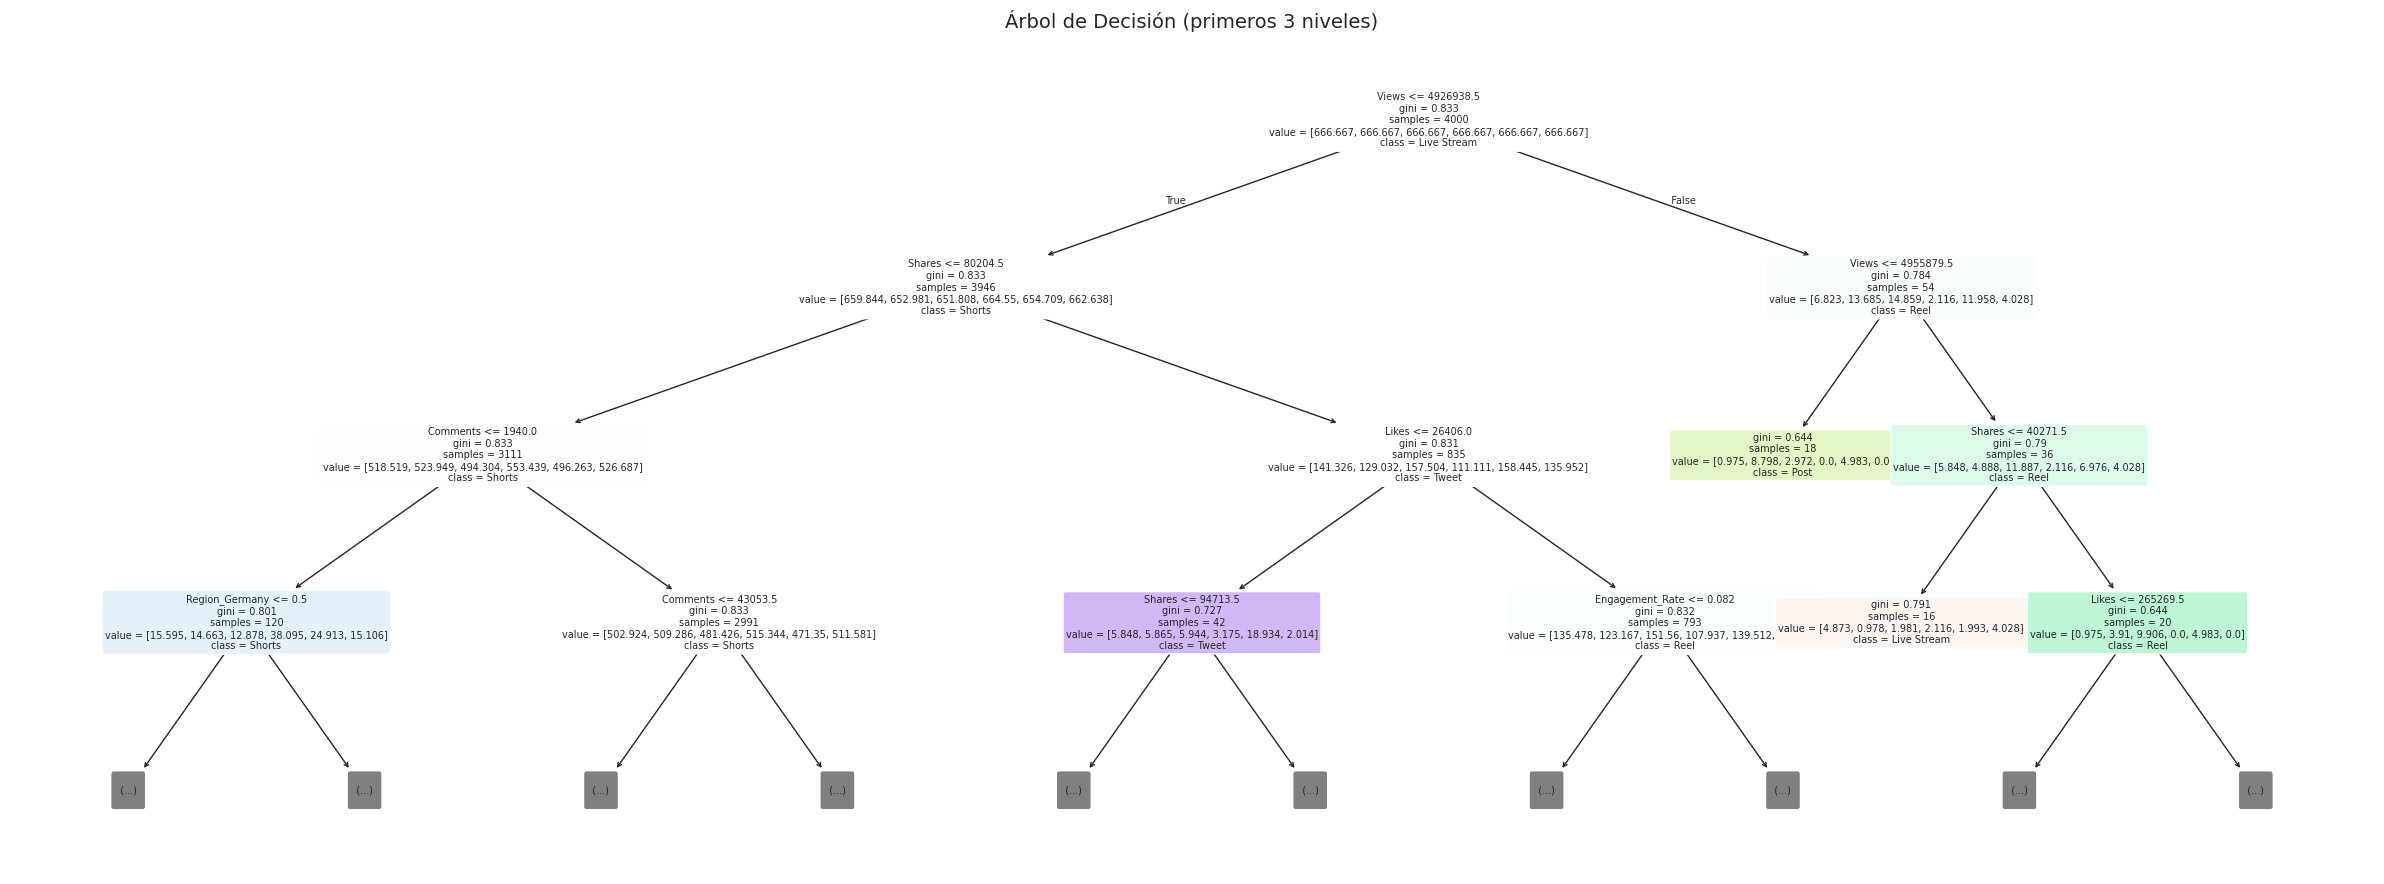

In [16]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(24, 9))
clf_dt = pipe_dt.named_steps['clf']
plot_tree(
    clf_dt,
    feature_names=list(features),
    class_names=list(clf_dt.classes_),
    filled=True, rounded=True, fontsize=7, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

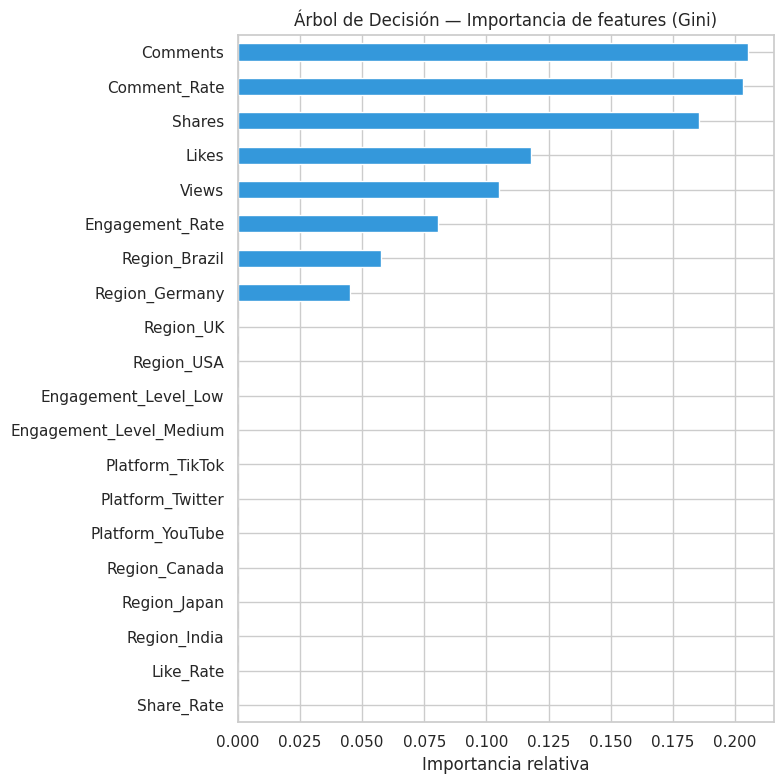

In [17]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


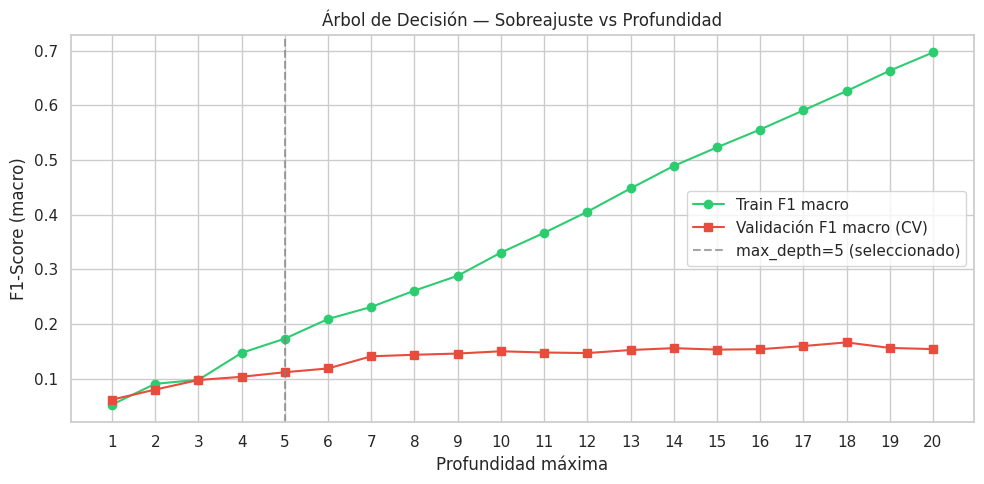

In [18]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train), average='macro'))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1_macro')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1 macro', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 macro (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score (macro)')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca los hiperplanos que maximizan el margen de separación entre clases (internamente, one-vs-one para multiclase). Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [19]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1_macro')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 macro CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 macro CV: 0.1537 ± 0.0170
SVM (rbf   ) — F1 macro CV: 0.1549 ± 0.0062
SVM (poly  ) — F1 macro CV: 0.1598 ± 0.0055

Mejor kernel: poly


In [20]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
proba_svm = pipe_svm.predict_proba(X_test)
scores_svm = svm_results[best_kernel]

In [21]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1_macro')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 macro = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 macro = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ En modelos basados en distancias, la estandarización suele ser importante,')
print('  sobre todo aquí donde Views está en el orden de millones y las tasas en [0, 1].')
print('  Si la diferencia observada es pequeña o incluso negativa, puede deberse al ruido')
print('  propio del CV en un dataset con señal predictiva débil (ver sección 10).')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 macro = 0.1598
  SIN StandardScaler: F1 macro = 0.0996
  Diferencia: +6.03 puntos porcentuales

→ En modelos basados en distancias, la estandarización suele ser importante,
  sobre todo aquí donde Views está en el orden de millones y las tasas en [0, 1].
  Si la diferencia observada es pequeña o incluso negativa, puede deberse al ruido
  propio del CV en un dataset con señal predictiva débil (ver sección 10).


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

K óptimo: 1


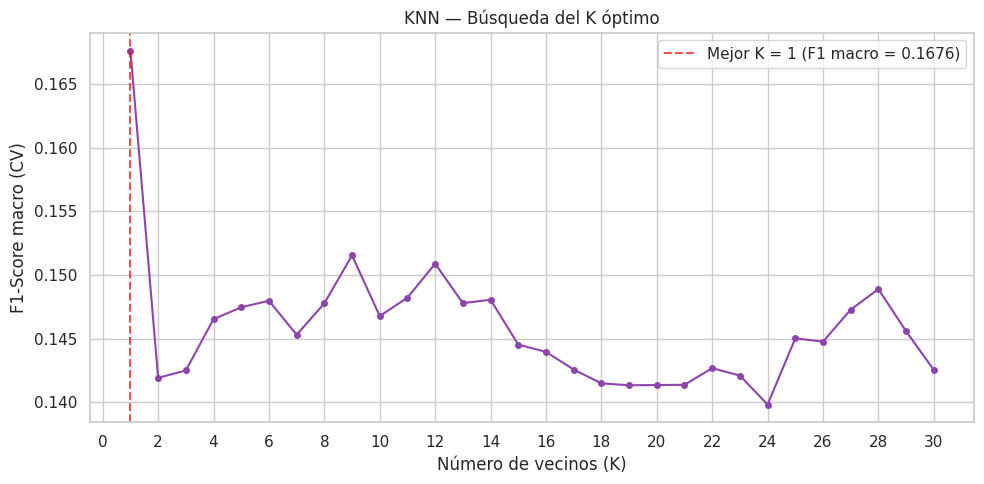

In [22]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1_macro')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 macro = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score macro (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [23]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1_macro')
print(f'KNN (K={best_k}) — F1 macro CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)
proba_knn = pipe_knn.predict_proba(X_test)

KNN (K=1) — F1 macro CV: 0.1676 ± 0.0073


---
## 9. Análisis comparativo de modelos

In [24]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, proba_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, proba_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, proba_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, proba_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, proba, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 macro CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 macro CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 macro Test': f'{f1_score(y_test, y_pred, average="macro"):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*85)
print('COMPARACIÓN DE MODELOS')
print('='*85)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 macro CV (mean),F1 macro CV (std),Accuracy Test,F1 macro Test
0,Logistic Regression,0.1549,0.0088,0.1620,0.1597
1,Decision Tree,0.1258,0.0199,0.1690,0.1266
2,SVM (poly),0.1598,0.0055,0.1830,0.1823
3,KNN (K=1),0.1676,0.0073,0.1850,0.1846


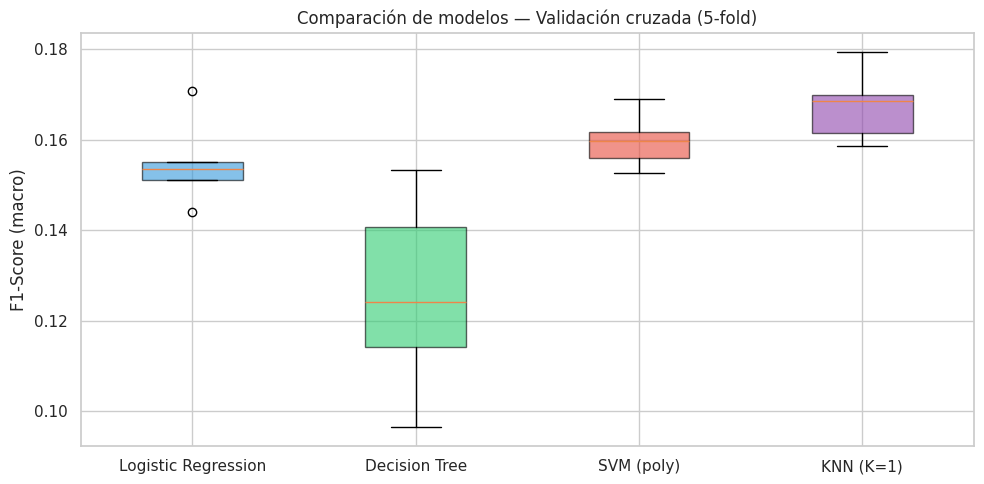

In [25]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score (macro)')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

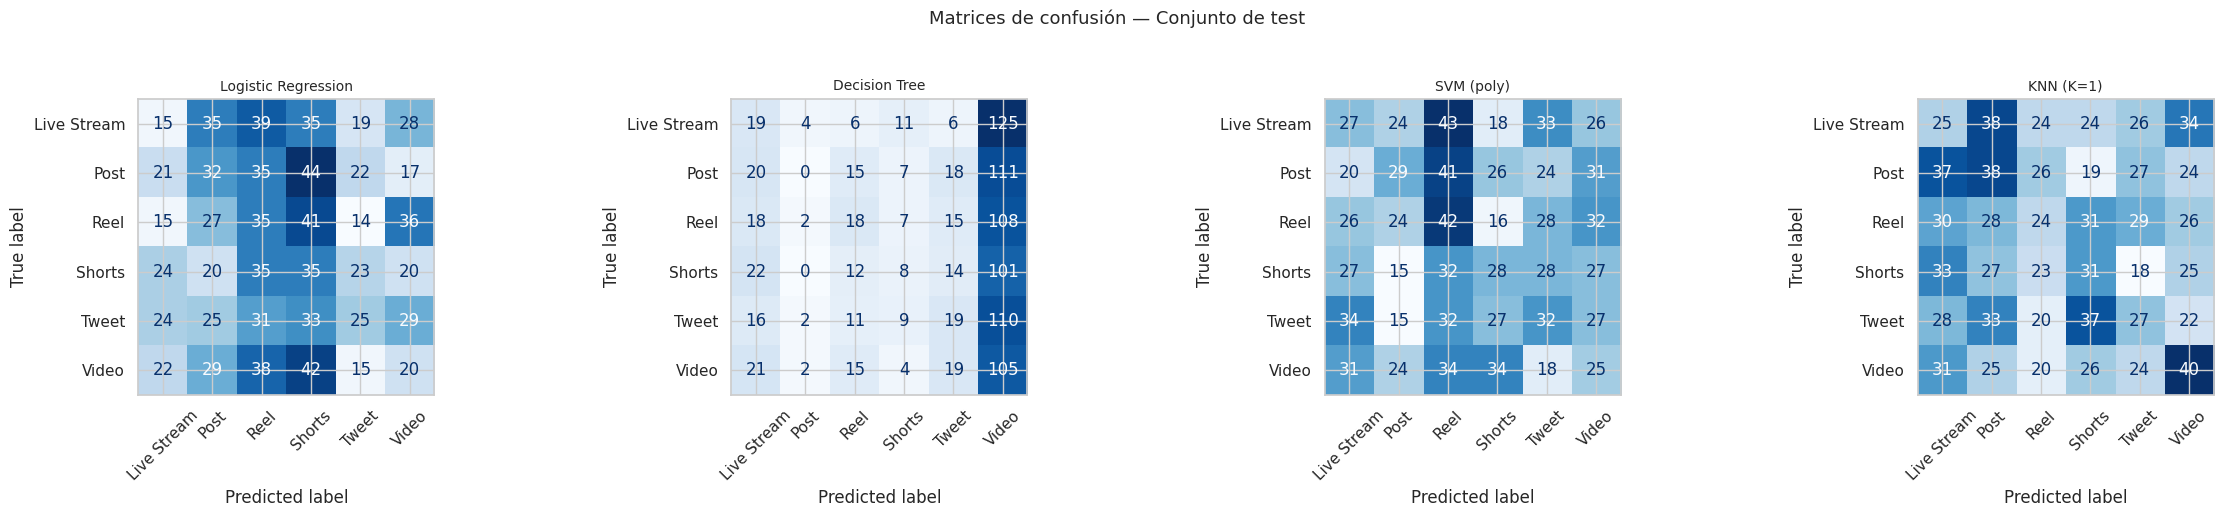

In [26]:
# 9.3  Matrices de confusión comparativas (6x6)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (name, (pipe, y_pred, _, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        labels=class_names,
        cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

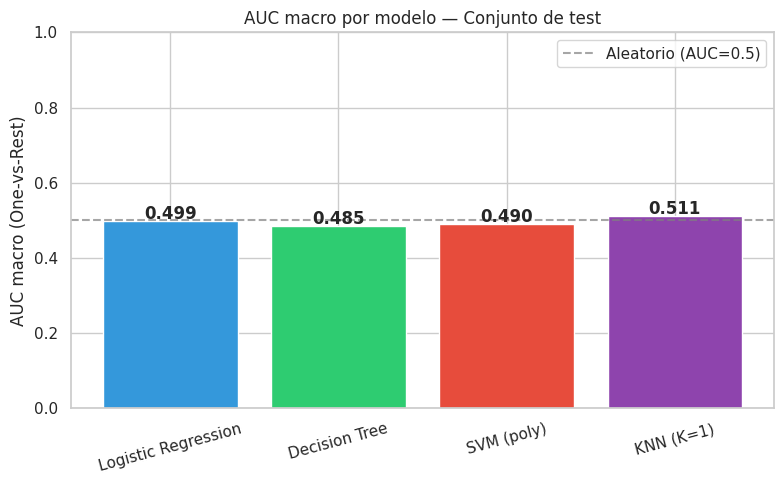

In [27]:
# 9.4  AUC macro (One-vs-Rest) comparativo
# Con 6 clases, graficar una curva ROC por clase y por modelo (24 líneas) no es legible;
# resumimos con el AUC macro-promedio (One-vs-Rest) de cada modelo.
auc_scores = {}
for name, (pipe, _, proba, _) in models.items():
    auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro', labels=pipe.classes_)
    auc_scores[name] = auc

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(auc_scores.keys(), auc_scores.values(),
              color=['#3498db', '#2ecc71', '#e74c3c', '#8e44ad'])
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Aleatorio (AUC=0.5)')
for bar, v in zip(bars, auc_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('AUC macro (One-vs-Rest)')
ax.set_title('AUC macro por modelo — Conjunto de test')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [28]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][3].mean()))
best_pipe, best_pred, best_proba, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*65)
print(classification_report(y_test, best_pred, labels=class_names, target_names=class_names))


Mejor modelo: KNN (K=1)
              precision    recall  f1-score   support

 Live Stream       0.14      0.15      0.14       171
        Post       0.20      0.22      0.21       171
        Reel       0.18      0.14      0.16       168
      Shorts       0.18      0.20      0.19       157
       Tweet       0.18      0.16      0.17       167
       Video       0.23      0.24      0.24       166

    accuracy                           0.18      1000
   macro avg       0.18      0.19      0.18      1000
weighted avg       0.18      0.18      0.18      1000



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes por clase), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar; multiclase vía one-vs-one | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

**Nota sobre este dataset:** en la sección 3 vimos que `Content_Type` está distribuido de forma casi idéntica entre plataformas, regiones y niveles de engagement — es decir, con las columnas disponibles no hay una señal fuerte que distinga un `Reel` de un `Tweet`. Si el F1 macro obtenido ronda 1/6 ≈ 0.17 (el nivel de un clasificador aleatorio con 6 clases balanceadas), esto es tan informativo como un buen desempeño: indica que, para predecir el tipo de contenido, se necesitarían features que hoy no están en el dataset (por ejemplo, texto o metadatos del propio contenido). Es un buen ejemplo de por qué el EDA (sección 3) debe hacerse *antes* de invertir tiempo en el modelado.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1 macro obtenido y compare contra el SVM base de este notebook.

### Ejercicio 2 — Comparación con Engagement_Level como objetivo
Repita el pipeline completo usando `Engagement_Level` (binarizado como `High` vs `Low/Medium`) como variable objetivo en lugar de `Content_Type`, usando `Content_Type` ahora como feature (one-hot). Compare el F1 obtenido contra el de este notebook. ¿Cuál variable resulta más predecible con las columnas disponibles? ¿Por qué?

### Ejercicio 3 — Ingeniería de features adicional
Incorpore `Hashtag` (10 categorías, vía one-hot) y features derivadas de `Post_Date` (por ejemplo, mes o día de la semana de publicación) al conjunto de features. Vuelva a entrenar los 4 modelos y determine si estas variables adicionales mejoran el F1 macro respecto al conjunto de features original de este notebook.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II — Adaptado a dataset propio: Viral Social Media Trends (variable objetivo: Content_Type)*